╒═════════╤══════════╤══════════╕
│ g(a)    │ t0 [s]   │ t0 [yr]  │
├─────────┼──────────┼──────────┤
│ 1       │ 4.30E+17 │ 1.36E+10 │
├─────────┼──────────┼──────────┤
│ a       │ 6.83E+17 │ 2.16E+10 │
├─────────┼──────────┼──────────┤
│ a**2    │ 1.43E+18 │ 4.54E+10 │
├─────────┼──────────┼──────────┤
│ sqrt(a) │ 5.30E+17 │ 1.68E+10 │
├─────────┼──────────┼──────────┤
│ exp(a)  │ 3.29E+17 │ 1.04E+10 │
├─────────┼──────────┼──────────┤
│ sin(a)  │ 6.99E+17 │ 2.22E+10 │
╘═════════╧══════════╧══════════╛


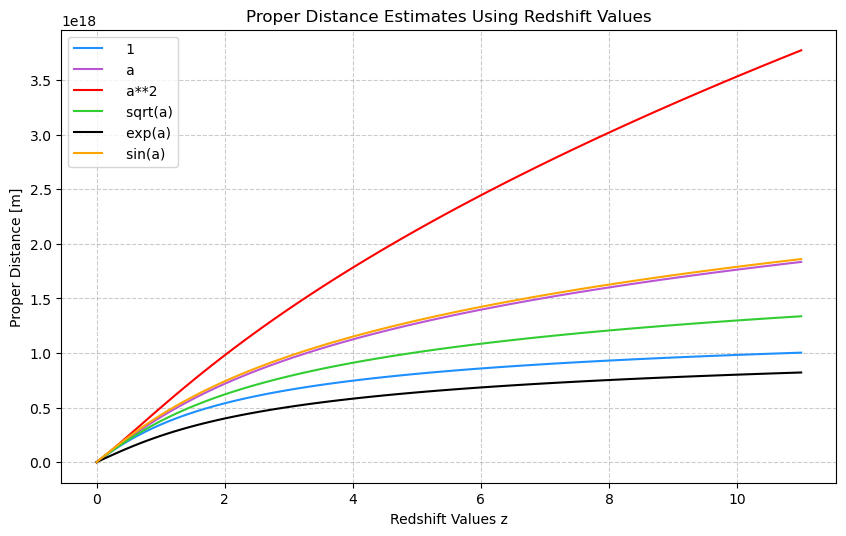

In [105]:
#Imports
import scipy.integrate as integrate
import matplotlib.pyplot as plt
from numpy import pi, sqrt, linspace, exp, sin
from tabulate import tabulate
from inspect import getsourcelines


#Constants
G = 6.67*10**-11  #Newton's gravitational constant [m^3 kg^-1 s^-2]
pc = 9*10**-27    #critical density of universe
m0 = 0.3          #density of matter
r0 = 0.000084     #density of radiation
v0 = 0.7          #density of vacuum


#The function age_of_universe_custom_gravity is used to evaluate age_of_universe for different specified functions g(a)
def age_of_universe_custom_gravity(g):
    #This function returns the argument for the integral of the age of the universe
    def age_of_universe(a):
        return sqrt((3*a**2)/(8*pi*G*g(a)*pc*(v0*a**4 + m0*a + r0)))
    return age_of_universe


#The function proper_distance_custom_gravity is used to evaluate proper_distance for different specified functions g(a)
def proper_distance_custom_gravity(g):    
    #This function returns the argument for the integral of the proper distance
    def proper_distance(a):
        return (sqrt((3*a**2)/(8*pi*G*g(a)*pc*(v0*a**4 + m0*a + r0))))/a
    return proper_distance


#These are the functions for which we will evaluate a scale-factor dependent gravity
functions = [
  lambda a: 1,
  lambda a: a,
  lambda a: a**2,
  lambda a: sqrt(a),
  lambda a: exp(a),
  lambda a: sin(a)
]


#Creating a table for the functions g(a) and the values of the age of the universe and creates graph for proper distances
table = [['g(a)','t0 [s]','t0 [yr]']]
redshift_range = linspace(0,11,100)  #z=0: in front of you; z=11: farthest galaxy measured in universe
dp_list_g = []

#This loop gives a string and then calculates the age of the universe in seconds and years for each function in functions
for index in range(len(functions)):
    rows = []
    #The following lines turn each function into a string and appends it to rows
    f = str(getsourcelines(functions[index])[0])
    f = f.strip("['\\n']").split(" = ")[0]
    f = f.strip(",")
    f = f.replace("lambda a:","")
    rows.append(f)
    
    #The following lines find the age of the universe values and appends them to rows
    #fixed_quad numerically integrates from a to b using Gaussian quadrature of order n; returns (value, none) in a tuple
    age_sec = integrate.fixed_quad(age_of_universe_custom_gravity(functions[index]), 0, 1, n=20)
    age_sec = age_sec[0]
    age_yr = age_sec*(3.17*10**-8)
    rows.append('{:.2E}'.format(age_sec))
    rows.append('{:.2E}'.format(age_yr))
    table.append(rows)

    #This loop numerically integrates the proper_distance function for each value in redshift_range and appends them to dp_list
    dp_list = []  #list for values of the proper distance
    for z in redshift_range:
        dp = integrate.fixed_quad(proper_distance_custom_gravity(functions[index]), 1/(1+z), 1, n=20)
        dp_list.append(dp[0])  #dp[0] gives the float value in the tuple
    dp_list_g.append(dp_list)

print(tabulate(table,tablefmt='fancy_grid'))

#Plotting the figure
color = ['dodgerblue','mediumorchid','red','limegreen','black','orange']  #different color for each curve
plt.figure(figsize=(10,6),dpi=100)
#This loop plots proper distance vs redshift value for each function g(a)
for index in range(len(dp_list_g)):
    plt.plot(redshift_range,dp_list_g[index],linestyle='solid',color=color[index],label=table[index+1][0])
plt.grid(True,alpha=0.6,linestyle='dashed',color='darkgray',which='both')
plt.legend(prop={'size':10})
plt.rcParams['legend.loc'] = 'upper left'
plt.title('Proper Distance Estimates Using Redshift Values')
plt.xlabel('Redshift Values z')
plt.ylabel('Proper Distance [m]')
plt.show()